# 01 Data Understanding and Quality Assessment

This notebook explores the **Credit Card Customers** dataset used for customer churn prediction.

The goal is to understand the dataset structure, target variable, feature types, missing values, placeholder missing values, identifier quality, and potential data leakage before reproducing the SAS Viya data preparation workflow in Python.

This notebook corresponds mainly to the **Data Exploration** stage of the original SAS Viya workflow.

## 1. Import Libraries

In [119]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

## 2. Load Dataset

The raw dataset is loaded from the `data/raw/` directory.

In [120]:
DATA_PATH = "../data/raw/BankChurners.csv"

df = pd.read_csv(DATA_PATH)

df.head()

,CLIENTNUM,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2
0,768805383,Existing Customer,45,M,3,High School,Married,$60K - $80K,Blue,39,5,1,3,12691.0,777,11914.0,1.335,1144,42,1.625,0.061,0.000093,0.99991
1,818770008,Existing Customer,49,F,5,Graduate,Single,Less than $40K,Blue,44,6,1,2,8256.0,864,7392.0,1.541,1291,33,3.714,0.105,0.000057,0.99994
2,713982108,Existing Customer,51,M,3,Graduate,Married,$80K - $120K,Blue,36,4,1,0,3418.0,0,3418.0,2.594,1887,20,2.333,0.000,0.000021,0.99998
3,769911858,Existing Customer,40,F,4,High School,Unknown,Less than $40K,Blue,34,3,4,1,3313.0,2517,796.0,1.405,1171,20,2.333,0.760,0.000134,0.99987
4,709106358,Existing Customer,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,5,1,0,4716.0,0,4716.0,2.175,816,28,2.500,0.000,0.000022,0.99998


## 3. Dataset Overview

This section checks the number of observations, number of variables, column names, and basic data types.

In [121]:
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]:,}")

Rows: 10,127
Columns: 23


In [122]:
df.columns.tolist()

['CLIENTNUM',
 'Attrition_Flag',
 'Customer_Age',
 'Gender',
 'Dependent_count',
 'Education_Level',
 'Marital_Status',
 'Income_Category',
 'Card_Category',
 'Months_on_book',
 'Total_Relationship_Count',
 'Months_Inactive_12_mon',
 'Contacts_Count_12_mon',
 'Credit_Limit',
 'Total_Revolving_Bal',
 'Avg_Open_To_Buy',
 'Total_Amt_Chng_Q4_Q1',
 'Total_Trans_Amt',
 'Total_Trans_Ct',
 'Total_Ct_Chng_Q4_Q1',
 'Avg_Utilization_Ratio',
 'Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1',
 'Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2']

In [123]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10127 entries, 0 to 10126
Data columns (total 23 columns):
 #   Column                                                                                                                              Non-Null Count  Dtype  
---  ------                                                                                                                              --------------  -----  
 0   CLIENTNUM                                                                                                                           10127 non-null  int64  
 1   Attrition_Flag                                                                                                                      10127 non-null  str    
 2   Customer_Age                                                                                                                        10127 non-null  int64  
 3   Gender                                                                                      

### Data Type Summary

The dataset contains a mixture of numerical and categorical variables. Understanding the data types helps determine appropriate preprocessing techniques such as encoding, scaling, and missing value treatment.

In [124]:
df.dtypes.value_counts().rename_axis("Data Type").reset_index(name="Count")

,Data Type,Count
0,int64,10
1,float64,7
2,str,6


### Initial Observation

The dataset contains customer-level demographic, account, credit, and transaction information.

The original SAS Viya report identifies this dataset as containing **10,127 customer records** and customer churn information derived from the `Attrition_Flag` variable.

## 4. Variable Roles

This section classifies variables into identifier, target, categorical predictors, numerical predictors, and leakage-related variables.

In [125]:
target_variable = "Attrition_Flag"
identifier_variable = "CLIENTNUM"

leakage_variables = [
    col for col in df.columns
    if col.startswith("Naive_Bayes_Classifier")
]

categorical_predictors = [
    col for col in df.select_dtypes(include=["object", "string"]).columns
    if col not in [target_variable]
]

numerical_predictors = [
    col for col in df.select_dtypes(include=["int64", "float64"]).columns
    if col not in [identifier_variable] + leakage_variables
]

variable_roles = []

for col in df.columns:
    if col == identifier_variable:
        role = "Identifier"
    elif col == target_variable:
        role = "Original Target"
    elif col in leakage_variables:
        role = "Leakage / Excluded"
    elif col in categorical_predictors:
        role = "Categorical Predictor"
    elif col in numerical_predictors:
        role = "Numerical Predictor"
    else:
        role = "Other"

    variable_roles.append({
        "Variable": col,
        "Data Type": str(df[col].dtype),
        "Role": role
    })

variable_roles_df = pd.DataFrame(variable_roles)

variable_roles_df

,Variable,Data Type,Role
0,CLIENTNUM,int64,Identifier
1,Attrition_Flag,str,Original Target
2,Customer_Age,int64,Numerical Predictor
3,Gender,str,Categorical Predictor
4,Dependent_count,int64,Numerical Predictor
5,Education_Level,str,Categorical Predictor
6,Marital_Status,str,Categorical Predictor
7,Income_Category,str,Categorical Predictor
8,Card_Category,str,Categorical Predictor
9,Months_on_book,int64,Numerical Predictor


In [126]:
feature_summary = pd.DataFrame({
    "Category": [
        "Identifier",
        "Target",
        "Categorical Predictors",
        "Numerical Predictors",
        "Leakage Variables"
    ],
    "Count": [
        1,
        1,
        len(categorical_predictors),
        len(numerical_predictors),
        len(leakage_variables)
    ]
})

feature_summary

,Category,Count
0,Identifier,1
1,Target,1
2,Categorical Predictors,5
3,Numerical Predictors,14
4,Leakage Variables,2


### Variable Role Notes

- `CLIENTNUM` is a customer identifier and should not be used as a predictive feature.
- `Attrition_Flag` is the original target variable.
- Two `Naive_Bayes_Classifier` columns are excluded because they represent prediction outputs from a previous model and may introduce data leakage.
- Remaining demographic, credit, and transaction variables are treated as candidate predictors.

## 5. Target Variable Analysis

The target variable is `Attrition_Flag`, which indicates whether a customer is an existing customer or an attrited customer.

For modelling, this will later be converted into a binary `Churn` variable:

- `Existing Customer` → `0`
- `Attrited Customer` → `1`

In [127]:
df["Attrition_Flag"].value_counts()

Attrition_Flag
Existing Customer    8500
Attrited Customer    1627
Name: count, dtype: int64

In [128]:
target_distribution = (
    df["Attrition_Flag"]
    .value_counts()
    .reset_index()
)

target_distribution.columns = ["Attrition_Flag", "Count"]

target_distribution["Percentage"] = (
    target_distribution["Count"] / len(df) * 100
).round(2)

target_distribution

,Attrition_Flag,Count,Percentage
0,Existing Customer,8500,83.93
1,Attrited Customer,1627,16.07


In [129]:
churn_rate = df["Attrition_Flag"].value_counts(normalize=True)

print(f"Existing customers : {churn_rate['Existing Customer']:.2%}")
print(f"Attrited customers : {churn_rate['Attrited Customer']:.2%}")

Existing customers : 83.93%
Attrited customers : 16.07%


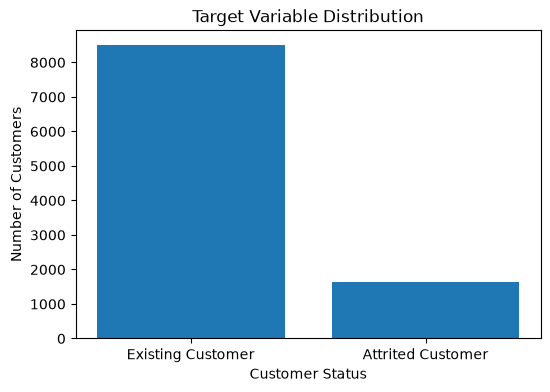

In [130]:
plt.figure(figsize=(6, 4))
plt.bar(target_distribution["Attrition_Flag"], target_distribution["Count"])
plt.title("Target Variable Distribution")
plt.xlabel("Customer Status")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)
plt.show()

In [193]:
df["Churn"] = df["Attrition_Flag"].map({
    "Existing Customer": 0,
    "Attrited Customer": 1
})

df[["Attrition_Flag", "Churn"]].sample(10)

,Attrition_Flag,Churn
8509,Existing Customer,0
3708,Existing Customer,0
8670,Existing Customer,0
8141,Existing Customer,0
5618,Attrited Customer,1
8433,Attrited Customer,1
1359,Existing Customer,0
8801,Existing Customer,0
4233,Attrited Customer,1
670,Existing Customer,0


### Target Variable Findings

The dataset is imbalanced, with the majority of customers classified as existing customers and a smaller proportion classified as attrited customers.

This corresponds to the binary target analysis in the SAS Viya report, where `Attrition_Flag` was converted into a binary churn target.

## 6. Duplicate Record Check

Duplicate records can distort model training and inflate performance estimates. This section checks whether identical rows exist in the dataset.

In [132]:
duplicate_count = df.duplicated().sum()

print(f"Duplicate rows: {duplicate_count}")

Duplicate rows: 0


No duplicate customer records were identified.

## 7. Customer Identifier Validation

The `CLIENTNUM` field represents the customer identifier. A valid customer-level dataset should have one unique identifier per customer record.

In [133]:
unique_customers = df["CLIENTNUM"].nunique()
total_rows = len(df)

print(f"Unique CLIENTNUM values: {unique_customers:,}")
print(f"Total rows: {total_rows:,}")
print(f"Each row has a unique customer ID: {unique_customers == total_rows}")

Unique CLIENTNUM values: 10,127
Total rows: 10,127
Each row has a unique customer ID: True


### Identifier Findings

Each record represents a unique customer. Therefore, `CLIENTNUM` should be retained only as an identifier and excluded from model training.

## 8. Technical Missing Value Assessment

This section checks for technical missing values represented as `NaN`.

In [134]:
missing_summary = (
    df.isna()
    .sum()
    .reset_index()
    .rename(columns={"index": "Variable", 0: "Missing Count"})
)

missing_summary["Missing (%)"] = (
    missing_summary["Missing Count"] / len(df) * 100
).round(2)

missing_summary.sort_values("Missing Count", ascending=False)

,Variable,Missing Count,Missing (%)
0,CLIENTNUM,0,0.0
1,Attrition_Flag,0,0.0
22,Naive_Bayes_Classifier_Attrition_Flag_Card_Cat...,0,0.0
21,Naive_Bayes_Classifier_Attrition_Flag_Card_Cat...,0,0.0
20,Avg_Utilization_Ratio,0,0.0
19,Total_Ct_Chng_Q4_Q1,0,0.0
18,Total_Trans_Ct,0,0.0
17,Total_Trans_Amt,0,0.0
16,Total_Amt_Chng_Q4_Q1,0,0.0
15,Avg_Open_To_Buy,0,0.0


### Technical Missing Value Findings

No technical missing values were detected using `isna()`.

However, this does not mean the dataset has no incomplete information. Some categorical variables use `"Unknown"` as a placeholder for missing or unavailable customer information.

## 9. Placeholder Missing Value Assessment

Some categorical fields contain `"Unknown"` values. These are not detected as `NaN`, but they represent incomplete information from a data quality perspective.

In [135]:
categorical_cols = df.select_dtypes(include=["object", "string"]).columns.tolist()

for col in categorical_cols:
    print(f"\n{col}")
    print(df[col].value_counts(dropna=False))


Attrition_Flag
Attrition_Flag
Existing Customer    8500
Attrited Customer    1627
Name: count, dtype: int64

Gender
Gender
F    5358
M    4769
Name: count, dtype: int64

Education_Level
Education_Level
Graduate         3128
High School      2013
Unknown          1519
Uneducated       1487
College          1013
Post-Graduate     516
Doctorate         451
Name: count, dtype: int64

Marital_Status
Marital_Status
Married     4687
Single      3943
Unknown      749
Divorced     748
Name: count, dtype: int64

Income_Category
Income_Category
Less than $40K    3561
$40K - $60K       1790
$80K - $120K      1535
$60K - $80K       1402
Unknown           1112
$120K +            727
Name: count, dtype: int64

Card_Category
Card_Category
Blue        9436
Silver       555
Gold         116
Platinum      20
Name: count, dtype: int64


In [136]:
unknown_counts = {}

for col in categorical_cols:
    unknown_count = (df[col] == "Unknown").sum()
    if unknown_count > 0:
        unknown_counts[col] = unknown_count

unknown_summary = (
    pd.DataFrame.from_dict(
        unknown_counts,
        orient="index",
        columns=["Unknown Count"]
    )
    .reset_index()
    .rename(columns={"index": "Variable"})
)

unknown_summary["Unknown (%)"] = (
    unknown_summary["Unknown Count"] / len(df) * 100
).round(2)

unknown_summary.sort_values("Unknown Count", ascending=False)

,Variable,Unknown Count,Unknown (%)
0,Education_Level,1519,15.00
2,Income_Category,1112,10.98
1,Marital_Status,749,7.40


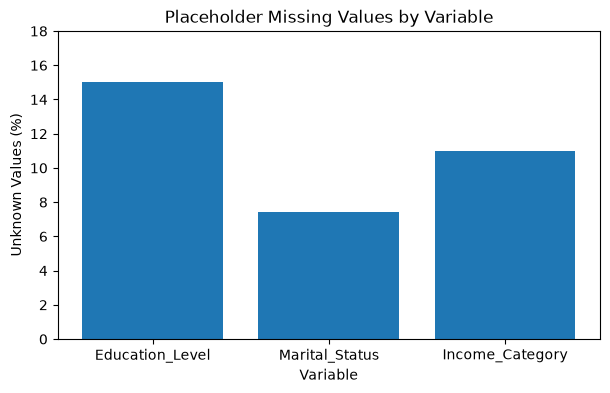

In [137]:
plt.figure(figsize=(7,4))

plt.bar(
    unknown_summary["Variable"],
    unknown_summary["Unknown (%)"]
)

plt.ylabel("Unknown Values (%)")
plt.xlabel("Variable")
plt.title("Placeholder Missing Values by Variable")

plt.ylim(0, 18)

plt.show()

Education_Level contains the highest proportion of placeholder missing values (15%), followed by Income_Category (10.98%) and Marital_Status (7.40%). These variables will require appropriate treatment during the data preparation stage.

### Placeholder Missing Value Findings

Three categorical variables contain `"Unknown"` values:

- `Education_Level`
- `Income_Category`
- `Marital_Status`

These values correspond to the data quality issues identified in the SAS Viya data preparation report.

In the next notebook, these variables will be handled through imputation and/or category consolidation depending on their modelling role.

## 10. Summary Statistics

This section reviews descriptive statistics for numerical variables to understand scale, spread, and potential outliers.

In [138]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
CLIENTNUM,10127.0,7.391776e+08,3.690378e+07,7.080821e+08,7.130368e+08,7.179264e+08,7.731435e+08,8.283431e+08
Customer_Age,10127.0,4.632596e+01,8.016814e+00,2.600000e+01,4.100000e+01,4.600000e+01,5.200000e+01,7.300000e+01
Dependent_count,10127.0,2.346203e+00,1.298908e+00,0.000000e+00,1.000000e+00,2.000000e+00,3.000000e+00,5.000000e+00
Months_on_book,10127.0,3.592841e+01,7.986416e+00,1.300000e+01,3.100000e+01,3.600000e+01,4.000000e+01,5.600000e+01
Total_Relationship_Count,10127.0,3.812580e+00,1.554408e+00,1.000000e+00,3.000000e+00,4.000000e+00,5.000000e+00,6.000000e+00
Months_Inactive_12_mon,10127.0,2.341167e+00,1.010622e+00,0.000000e+00,2.000000e+00,2.000000e+00,3.000000e+00,6.000000e+00
Contacts_Count_12_mon,10127.0,2.455317e+00,1.106225e+00,0.000000e+00,2.000000e+00,2.000000e+00,3.000000e+00,6.000000e+00
Credit_Limit,10127.0,8.631954e+03,9.088777e+03,1.438300e+03,2.555000e+03,4.549000e+03,1.106750e+04,3.451600e+04
Total_Revolving_Bal,10127.0,1.162814e+03,8.149873e+02,0.000000e+00,3.590000e+02,1.276000e+03,1.784000e+03,2.517000e+03
Avg_Open_To_Buy,10127.0,7.469140e+03,9.090685e+03,3.000000e+00,1.324500e+03,3.474000e+03,9.859000e+03,3.451600e+04


## 11. Correlation Analysis

This section examines linear relationships between numerical variables to identify highly correlated features that may influence feature engineering and model interpretation.

In [139]:
corr = df[numerical_predictors].corr()

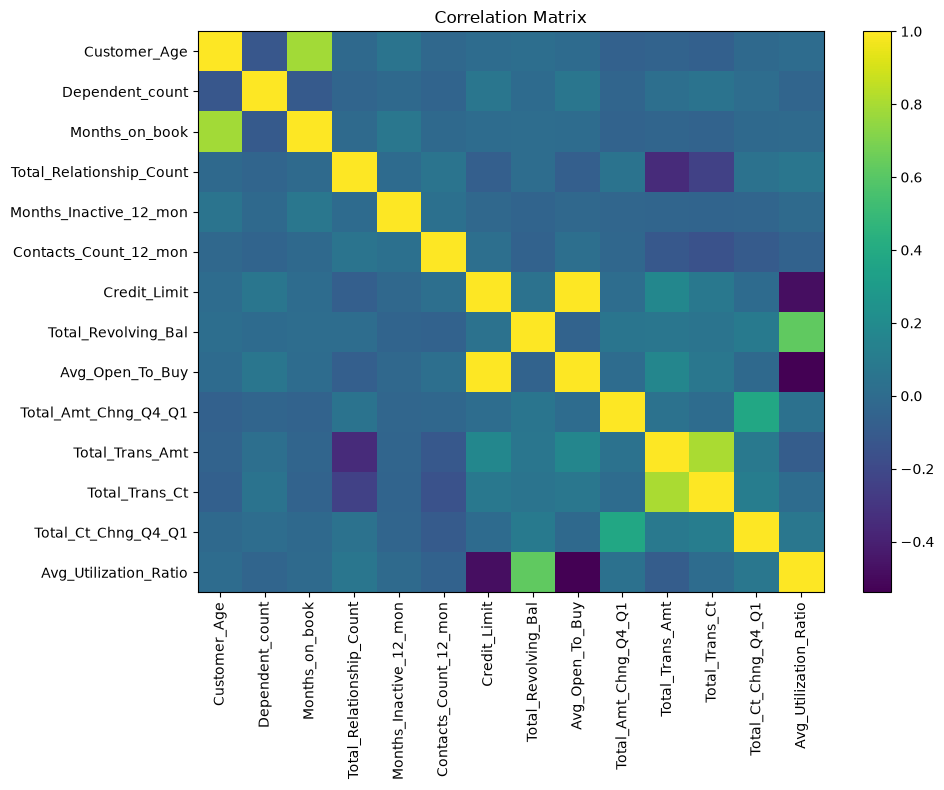

In [140]:
plt.figure(figsize=(10,8))

plt.imshow(corr, aspect="auto")
plt.colorbar()

plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)

plt.title("Correlation Matrix")

plt.tight_layout()
plt.show()

No severe multicollinearity is observed among the numerical predictors, although Customer_Age and Months_on_book exhibit a relatively strong positive correlation, which is expected since longer-tenured customers tend to be older.

## 12. Key Numerical Feature Distributions

The SAS Viya report identified several transaction, credit, and utilization variables as important for churn analysis.

This section visualizes selected numerical variables to inspect their distributions.

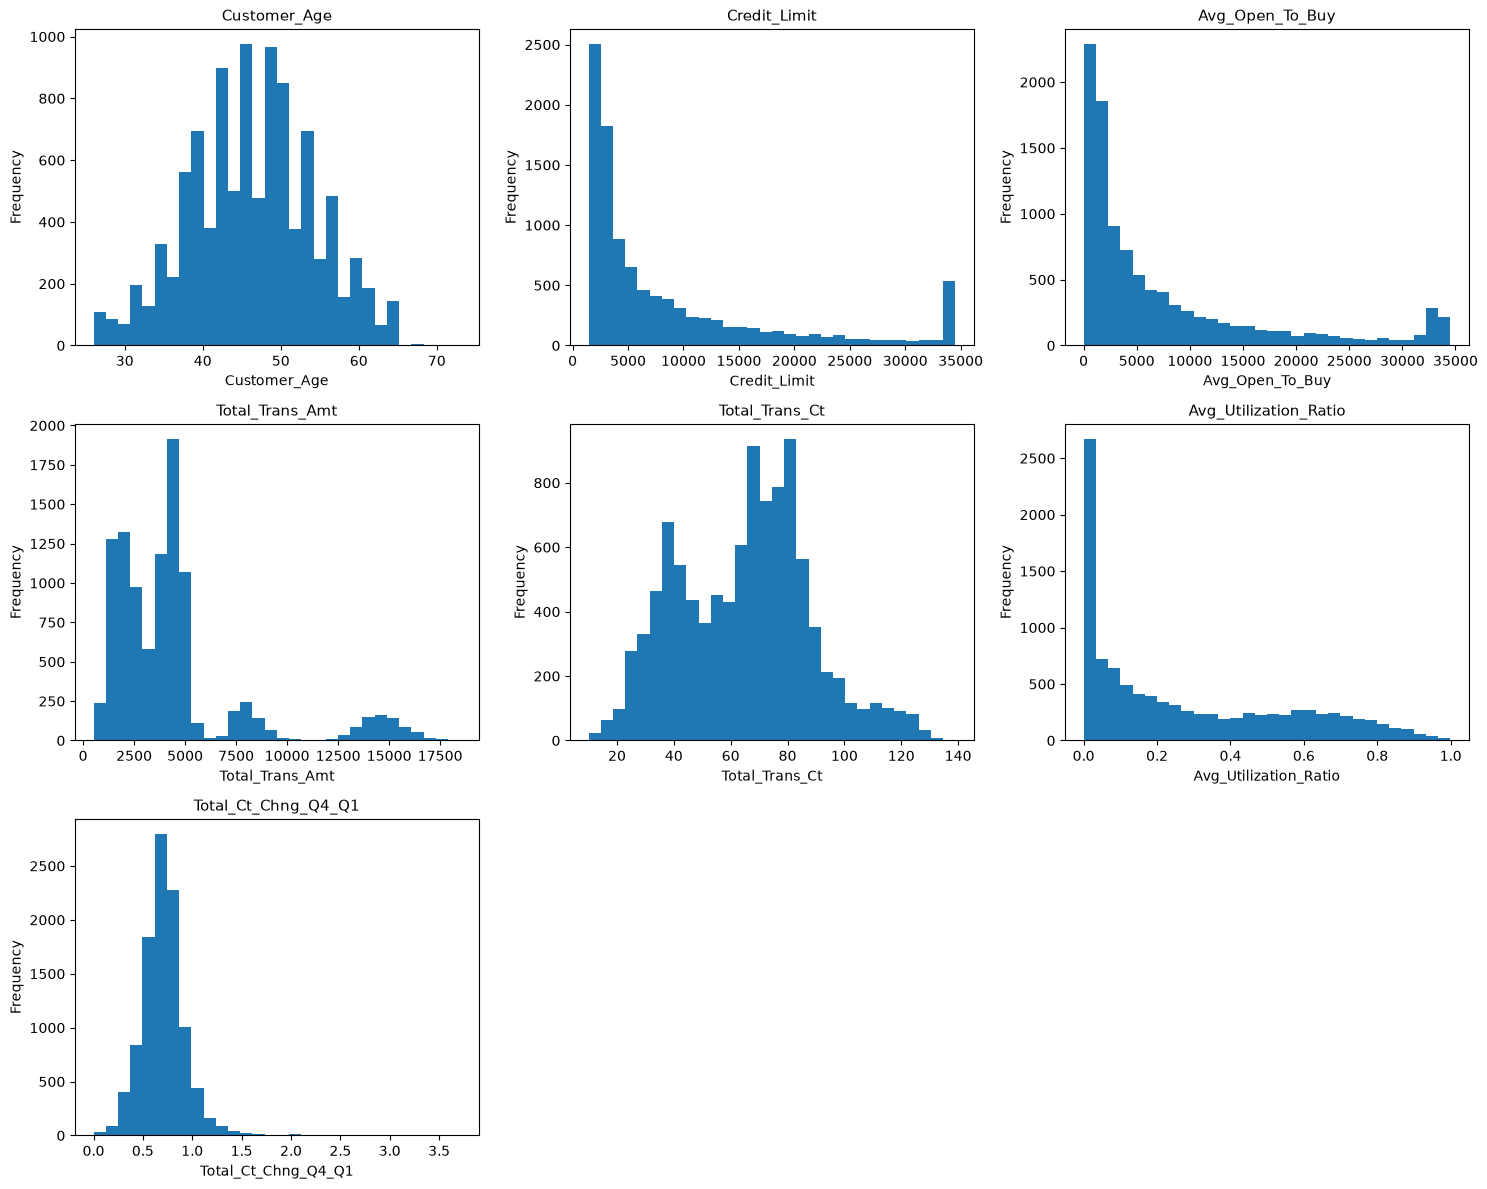

In [194]:
selected_numeric_features = [
    "Customer_Age",
    "Credit_Limit",
    "Avg_Open_To_Buy",
    "Total_Trans_Amt",
    "Total_Trans_Ct",
    "Avg_Utilization_Ratio",
    "Total_Ct_Chng_Q4_Q1"
]

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for i, col in enumerate(selected_numeric_features):
    axes[i].hist(df[col], bins=30)
    axes[i].set_title(col, fontsize=11)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Frequency")

# Hide unused subplots
for j in range(len(selected_numeric_features), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

### Distribution Findings

Several numerical variables show skewed distributions. Credit_Limit, Avg_Open_To_Buy, and Avg_Utilization_Ratio exhibit noticeable right-skewness. These variables may benefit from logarithmic transformation during preprocessing.

This corresponds to the skewness analysis in the SAS Viya report, where variables such as `Avg_Utilization_Ratio`, `Avg_Open_To_Buy`, and `Credit_Limit` were identified for log transformation.

Detailed skewness treatment will be handled in the data preparation notebook.

## 13. Churn Group Comparison

This section compares selected numerical variables between existing and attrited customers.

In [142]:
churn_group_summary = (
    df.groupby("Churn")[selected_numeric_features]
    .mean()
    .T
    .rename(columns={0: "Existing Customer", 1: "Attrited Customer"})
)

churn_group_summary.round(2)

Churn,Existing Customer,Attrited Customer
Customer_Age,46.26,46.66
Credit_Limit,8726.88,8136.04
Avg_Open_To_Buy,7470.27,7463.22
Total_Trans_Amt,4654.66,3095.03
Total_Trans_Ct,68.67,44.93
Avg_Utilization_Ratio,0.30,0.16
Total_Ct_Chng_Q4_Q1,0.74,0.55


### Churn Group Findings

The comparison helps identify behavioural differences between existing and attrited customers.

In the SAS Viya report, churned customers were observed to have lower transaction activity and lower changes in transaction behaviour. This Python analysis provides a reproducible basis for validating those patterns.

### Business Insights

The exploratory analysis highlights several business-relevant observations:

- Customer churn affects approximately **16%** of customers.
- Transaction behaviour differs substantially between existing and attrited customers.
- Customer demographic variables contain placeholder "Unknown" values that require treatment before modelling.
- Credit-related variables exhibit right-skewed distributions, indicating the need for transformation during preprocessing.
- No duplicate customer records were identified, suggesting good overall data integrity.

## 14. Removing Data Leakage Variables

The original dataset contains two `Naive_Bayes_Classifier` columns.

These columns are prediction outputs from a previously trained Naive Bayes model included in the Kaggle dataset. They should not be used as predictors because they would leak model-generated information into the training process and artificially inflate performance.

In [143]:
leakage_cols = [
    col for col in df.columns
    if col.startswith("Naive_Bayes_Classifier")
]

leakage_cols

['Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1',
 'Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2']

In [144]:
df = df.drop(columns=leakage_cols)

print(f"Shape after removing leakage variables: {df.shape}")

Shape after removing leakage variables: (10127, 22)


### Data Leakage Findings

The two Naive Bayes probability columns were removed before model development.

This step improves the validity of the future modelling workflow by ensuring that only original customer attributes are used as predictive features.

## Data Quality Assessment Summary

In [145]:
summary = pd.DataFrame({
    "Check":[
        "Rows",
        "Columns (before cleaning)",
        "Duplicate Records",
        "Technical Missing Values",
        "Placeholder Missing Variables",
        "Leakage Variables",
        "Churn Rate"
    ],
    "Result":[
        len(df),
        df.shape[1] + len(leakage_cols),       # before dropping leakage columns and after adding Churn
        duplicate_count,
        0,
        3,
        len(leakage_cols),
        f"{df['Churn'].mean()*100:.2f}%"
    ]
})

summary

,Check,Result
0,Rows,10127
1,Columns (before cleaning),24
2,Duplicate Records,0
3,Technical Missing Values,0
4,Placeholder Missing Variables,3
5,Leakage Variables,2
6,Churn Rate,16.07%


## 15. Final Data Quality Summary

This notebook completed the initial data understanding and quality assessment stage.

Key findings:

- The dataset contains 10,127 customer records.
- The target variable is imbalanced, with attrited customers forming the minority class.
- No technical missing values were detected.
- Placeholder `"Unknown"` values were found in selected categorical variables.
- `CLIENTNUM` is a unique identifier and should not be used for modelling.
- Two Naive Bayes prediction columns were removed to prevent data leakage.
- Several numerical variables show skewed distributions and will require further treatment.

The next notebook will reproduce the SAS Viya data preparation workflow in Python, including imputation, category consolidation, skewness treatment, and processed dataset creation.

## Next Steps

The next notebook, **02_data_preparation.ipynb**, will reproduce the SAS Viya data preparation workflow by:

- Handling placeholder "Unknown" values
- Consolidating categorical variables
- Applying skewness transformations
- Preparing modelling features
- Exporting a clean modelling dataset